<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15565/2473440733.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(mu, color='red', linestyle='--', label=f'Long-term Mean ($\mu$ = {mu})')
/tmp/ipykernel_15565/2473440733.py:38: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'Ornstein-Uhlenbeck Process ($\theta$={theta}, $\sigma$={sigma})')


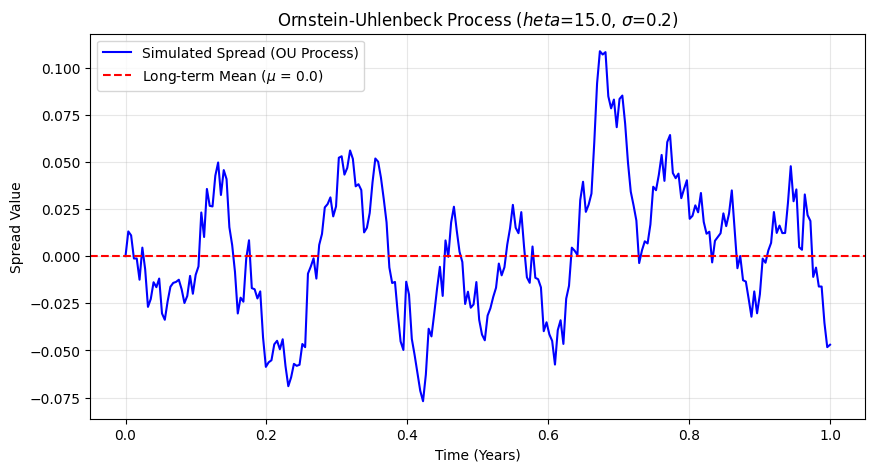

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Tools.figure_style import set_figure_style

def simulate_ou_process(theta, mu, sigma, x0, T, dt):
    """
    Simulates an Ornstein-Uhlenbeck process.
    """
    N = int(T / dt)
    x = np.zeros(N)
    x[0] = x0
    
    for t in range(1, N):
        # Generate random shock
        dW = np.sqrt(dt) * np.random.normal()
        # Euler-Maruyama discretization
        x[t] = x[t-1] + theta * (mu - x[t-1]) * dt + sigma * dW
        
    return x

# Time parameters
T = 1.0           # 1 year simulation
dt = 1/252        # Daily time step (assuming 252 trading days in a year)

# "Typical" Daily Pairs Trading Parameters
mu = 0.0          # Long-term mean (spreads are typically normalized to mean 0)
theta = 15.0      # Mean reversion speed. Half-life = ln(2)/15 ≈ 0.046 yrs (~11.6 days)
sigma = 0.2       # Volatility of the spread
x0 = 0.0          # Initial spread (e.g., starting 2.5 standard deviations away from mean)

# Run simulation
time_axis = np.linspace(0, T, int(T/dt))
spread = simulate_ou_process(theta, mu, sigma, x0, T, dt)

# Plotting
plt.figure(figsize=(10, 5))
set_figure_style()  # Apply custom figure style
plt.plot(time_axis, spread, label='Simulated Spread (OU Process)')
plt.axhline(mu, color='red', linestyle='--', label=f'Long-term Mean ($\mu$ = {mu})')
plt.title(f'Ornstein-Uhlenbeck Process ($\theta$={theta}, $\sigma$={sigma})')
plt.xlabel('Time (Years)')
plt.ylabel('Spread Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()